In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from scipy.stats import linregress
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster._dbscan import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [108]:
def get_slope(serie):
    """Calcula la pendiente (tendencia) de la regresión lineal en la ventana."""
    if len(serie) < 2 or np.isnan(serie).all():
        return np.nan
    x = np.arange(len(serie))
    # linregress retorna (slope, intercept, rvalue, pvalue, stderr)
    return linregress(x, serie).slope

In [109]:
df = pd.read_csv('../../datasets/esa_anomaly_193.zip', index_col=0)
df.index = pd.to_datetime(df.index)
df

,channel_44,channel_45,channel_46,anomaly
datetime,,,,
2000-06-15 00:00:28.335000+00:00,0.794538,0.810940,0.780363,0
2000-06-15 00:00:58.335000+00:00,0.796347,0.812064,0.779563,0
2000-06-15 00:01:28.335000+00:00,0.795454,0.812248,0.779874,0
2000-06-15 00:01:58.335000+00:00,0.795646,0.812370,0.780926,0
2000-06-15 00:02:28.335000+00:00,0.795249,0.813865,0.779375,0
...,...,...,...,...
2000-06-28 23:57:58.332000+00:00,0.796794,0.820271,0.773708,0
2000-06-28 23:58:28.332000+00:00,0.797064,0.820828,0.773437,0
2000-06-28 23:58:58.332000+00:00,0.796195,0.821199,0.774664,0


#### Extracción de características en ventana deslizante
Tomar una ventana y para cada ventana calcular, media desviacion estandar, maximos, minimos, tendencias (potencialmente spectral energy). Escalar y verificar con dbscan si tenemos outliers.


Voy  a trabajar unicamente con el canal 44

In [110]:
df = df[["channel_44", "anomaly"]]

In [111]:
# Frecuencia objetivo y tamano de la ventana temporal.
target_freq = "30s"


# El indice temporal debe estar ordenado y sin timestamps repetidos para resamplear.
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]

# Se agregan observaciones dentro de cada intervalo de 30 segundos.
df_regular = df.resample(target_freq).agg(
    {"channel_44": "mean", "anomaly": "first"}
)
df_regular["channel_44"] = df_regular["channel_44"].interpolate(method="time")
df_regular["anomaly"] = (
    df_regular["anomaly"].ffill().bfill().round().astype("int8")
)


In [112]:
df_noAnomaly = df_regular.loc[(df_regular.index>=df_regular.index.min()) & ((df_regular.index<=df_regular.index.min()+pd.Timedelta(days=6))),:]
df_anomaly = df_regular.loc[df_regular.index.difference(df_noAnomaly.index)]

In [113]:
DF_WITH_ANOMALY = True

def extract_features(df:pd.DataFrame, window_minutes:int) -> pd.DataFrame:
    # La pendiente se calcula sobre las muestras de la serie ya regularizada.
    rolling_window = f"{window_minutes}min"
    rolling_channel = df["channel_44"].rolling(
        window=rolling_window,
        min_periods=2,
    )

    df_features = pd.DataFrame(
        {
            "channel_44_mean": rolling_channel.mean(),
            "channel_44_std": rolling_channel.std(),
            "channel_44_max": rolling_channel.max(),
            "channel_44_min": rolling_channel.min(),
            "channel_44_slope": rolling_channel.apply(get_slope, raw=False),
            "anomaly": df["anomaly"],
        },
        index=df.index,
    ).dropna(subset=["channel_44_mean", "channel_44_std", "channel_44_slope"])
    return df_features

if DF_WITH_ANOMALY:
    df_features = extract_features(df=df_anomaly, window_minutes = 20)
else:
    df_features = extract_features(df=df_noAnomaly, window_minutes = 20)



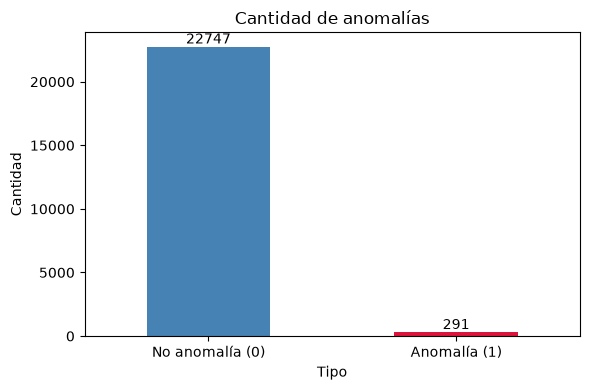

In [114]:
conteo_anomalias = (
    df_features["anomaly"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

ax = conteo_anomalias.plot(
    kind="bar",
    color=["steelblue", "crimson"],
    figsize=(6, 4),
)

ax.set_xlabel("Tipo")
ax.set_ylabel("Cantidad")
ax.set_title("Cantidad de anomalías")
ax.set_xticklabels(["No anomalía (0)", "Anomalía (1)"], rotation=0)

for barra, valor in zip(ax.patches, conteo_anomalias):
    ax.annotate(
        str(valor),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [115]:
features = list(df_features.columns)
features.remove("anomaly")
ss = StandardScaler()
ss.fit(df_features[features])
ss.transform(df_features[features])
df_features[features] = ss.transform(df_features[features])


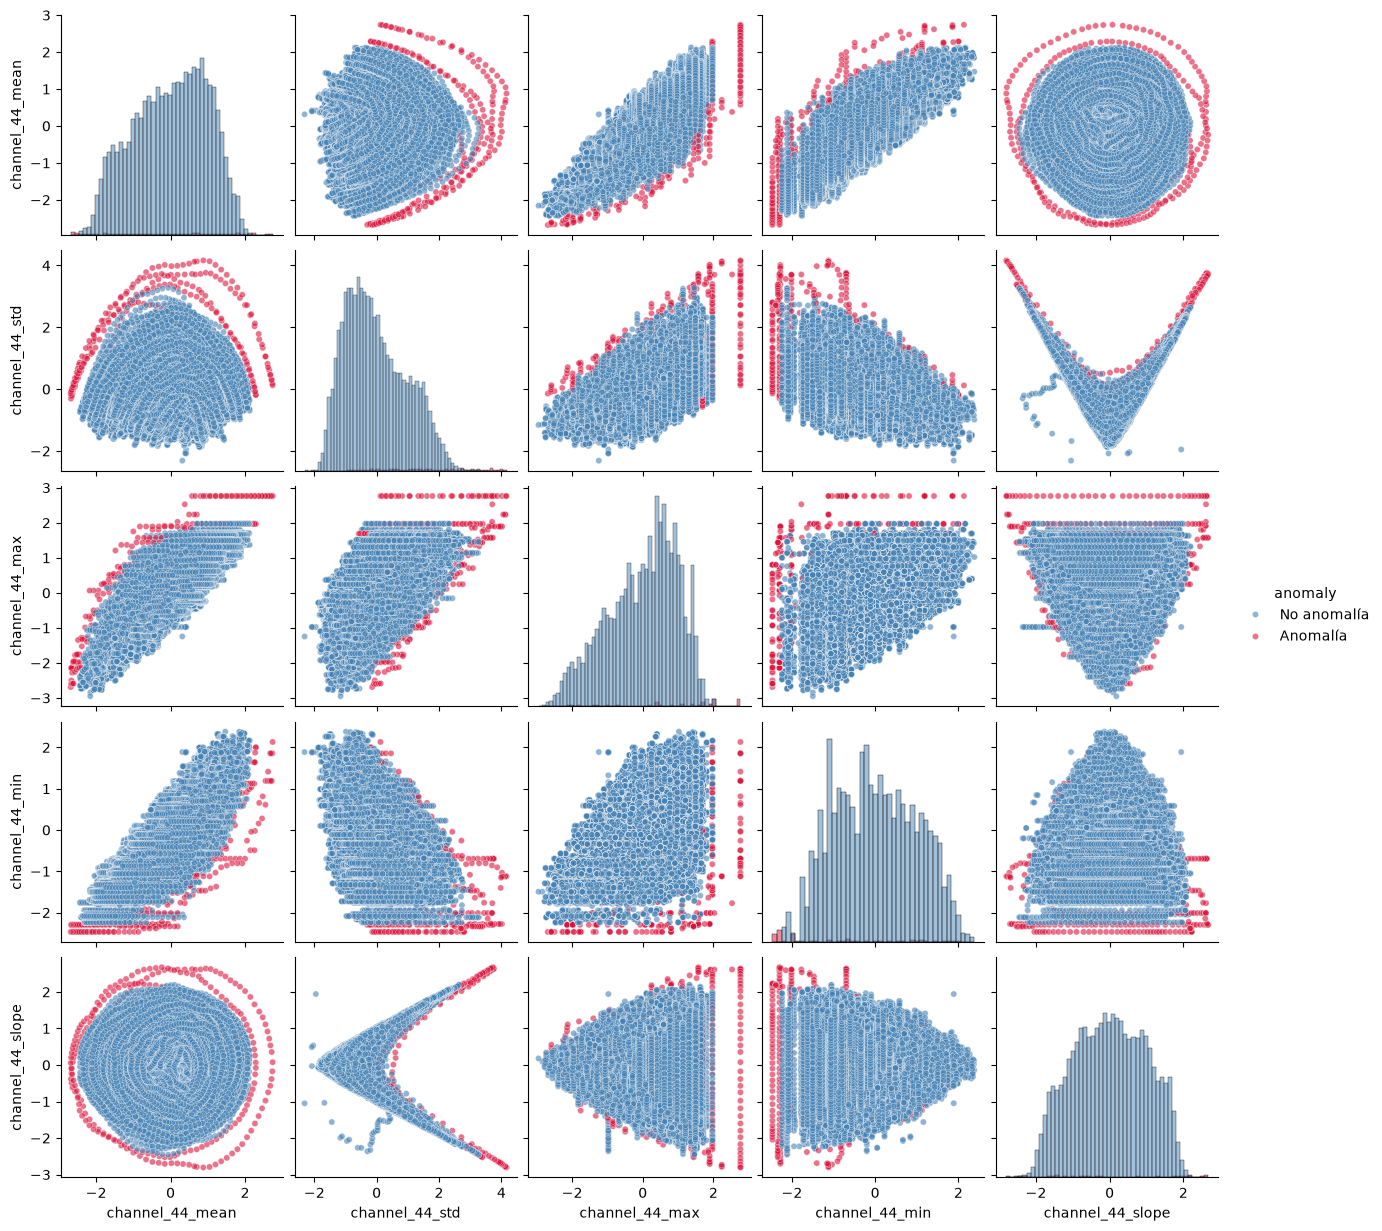

In [116]:
features = [
    "channel_44_mean",
    "channel_44_std",
    "channel_44_max",
    "channel_44_min",
    "channel_44_slope",
]

df_pairplot = df_features[features + ["anomaly"]].dropna().copy()
df_pairplot["anomaly"] = df_pairplot["anomaly"].map(
    {0: "No anomalía", 1: "Anomalía"}
)

sns.pairplot(
    df_pairplot,
    vars=features,
    hue="anomaly",
    palette={"No anomalía": "steelblue", "Anomalía": "crimson"},
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 20},
)


In [117]:
df_dbscan = df_features[["channel_44_max", "channel_44_std", "anomaly"]]
#df_dbscan.loc[df_dbscan["anomaly"]==1, ["channel_44_max"]]

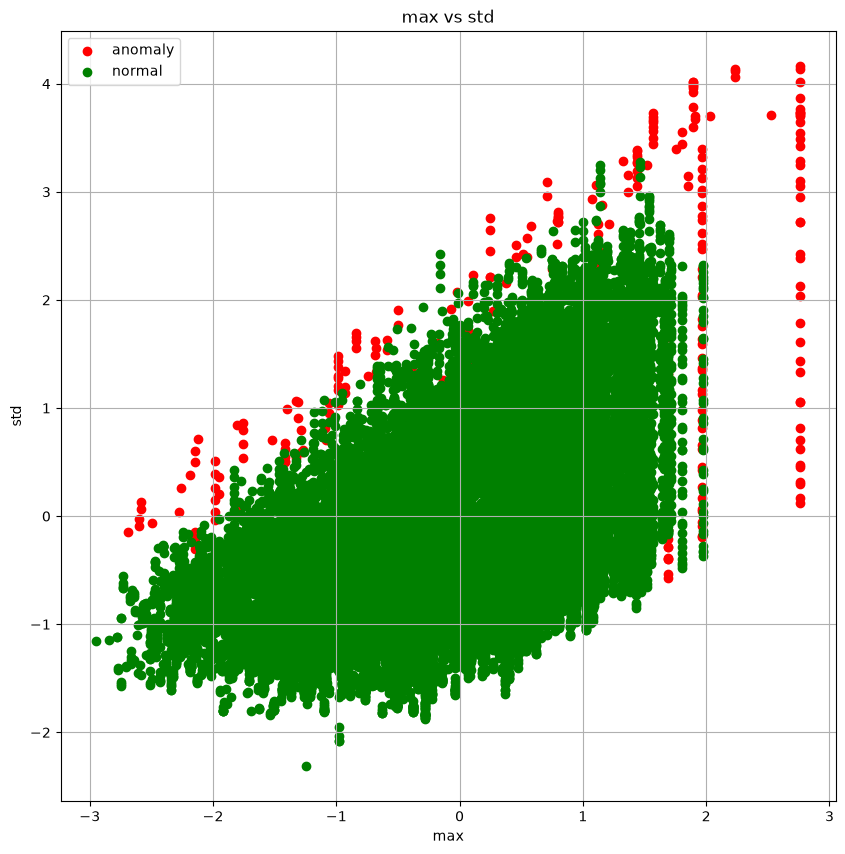

In [118]:
plt.figure(figsize=(10, 10))
plt.scatter(df_dbscan.loc[df_dbscan["anomaly"]==1, ["channel_44_max"]], df_dbscan.loc[df_dbscan["anomaly"]==1, ["channel_44_std"]], label='anomaly', color='red')
plt.scatter(df_dbscan.loc[df_dbscan["anomaly"]!=1, ["channel_44_max"]], df_dbscan.loc[df_dbscan["anomaly"]!=1, ["channel_44_std"]], label='normal', color='green')

plt.title('max vs std')
plt.xlabel('max')
plt.ylabel('std')
plt.legend()
plt.grid()
plt.show()

## Heurísticas en la calibración de eps y min_samples

¿Cúal es el porcentaje de anomalías? Puede considerarse trampa, pero tambien es posible suponer que la cantidad de anomalías se mantiene estable. Nosotros la podemos calcular pero también puede ser una especificación del fabricante.



In [119]:
df_dbscan["anomaly"].value_counts(normalize=True) * 100

anomaly
0    98.73687
1     1.26313
Name: proportion, dtype: float64

In [122]:
target_contamination    = 0.0126313
tolerance               = 0.005
max_iter                = 20

n_samples                = df_dbscan.shape[0]
db_scan_features        = ["channel_44_max", "channel_44_std"]
n_features              = len(db_scan_features)
min_samples_range       = [n_features + 1, n_features * 2, n_features * 3, n_features * 4]
target_anomalies        = int(n_samples * target_contamination)

In [ ]:
X           = df_dbscan[db_scan_features]
resultados  = []
for ms in sorted(list(set(min_samples_range))):
    nbrs            = NearestNeighbors(n_neighbors=ms)
    nbrs.fit(X)
    distances, _    = nbrs.kneighbors(X)
    k_distances     = np.sort(distances[:, -1])
    # Cotas para la búsqueda binaria de eps
                
    idx_target  = max(0, n_samples - target_anomalies)
    eps_low     = k_distances[max(0, idx_target - int(target_anomalies * 0.8))]
    eps_high    = k_distances[min(n_samples - 1, idx_target + int(target_anomalies * 0.8))]
    
    best_eps_for_ms = None
    best_diff = float('inf')
    best_labels = None
    for _ in range(max_iter):
        mid_eps = (eps_low + eps_high) / 2.0
        model = DBSCAN(eps=mid_eps, min_samples=ms)
        model.fit(X)
        labels = model.labels_

        n_anomalies = np.sum(labels == -1)
        diff = abs(n_anomalies - target_anomalies)

        if diff < best_diff:
            best_diff = diff
            best_eps_for_ms = mid_eps
            best_labels = labels
            
        if diff <= (n_samples * tolerance):
            break
            
        if n_anomalies > target_anomalies:
            eps_low = mid_eps
        else:
            eps_high = mid_eps

        actual_noise_ratio = np.sum(best_labels == -1) / n_samples
        unique_clusters = set(best_labels) - {-1}
        n_clusters = len(unique_clusters)
        
        # Calcular Silhouette solo sobre datos clasificados en clusters (no ruido)
        score_silhouette = -1.0
        if n_clusters >= 2:
            mask = best_labels != -1
            if np.sum(mask) > n_clusters:
                score_silhouette = silhouette_score(X[mask], best_labels[mask])
                
        resultados.append({
            'min_samples': ms,
            'eps': best_eps_for_ms,
            'noise_ratio_actual': actual_noise_ratio,
            'error_abs_anomalies': best_diff,
            'n_clusters': n_clusters,
            'silhouette_score': score_silhouette
        })
        
df_res = pd.DataFrame(resultados)

# Filtrar soluciones viables (que hayan formado al menos 2 clusters)
df_valid = df_res[df_res['n_clusters'] >= 2].sort_values(by='silhouette_score', ascending=False)

df_valid.reset_index(drop=True)
df_valid.head()


,min_samples,eps,noise_ratio_actual,error_abs_anomalies,n_clusters,silhouette_score
0,8,0.192669,0.003646,206,2,0.590698
1,8,0.143050,0.007119,126,6,0.093873
2,6,0.152631,0.003690,205,8,-0.056522
3,6,0.114668,0.007249,123,12,-0.093893
4,4,0.111839,0.004297,191,17,-0.285477
5,3,0.085304,0.005469,164,44,-0.447486


-----

In [ ]:

model = DBSCAN(eps=0.192, min_samples=8, metric="euclidean")
X["cluster"] = model.fit_predict(X)
X["anomaly"] = df_dbscan["anomaly"]

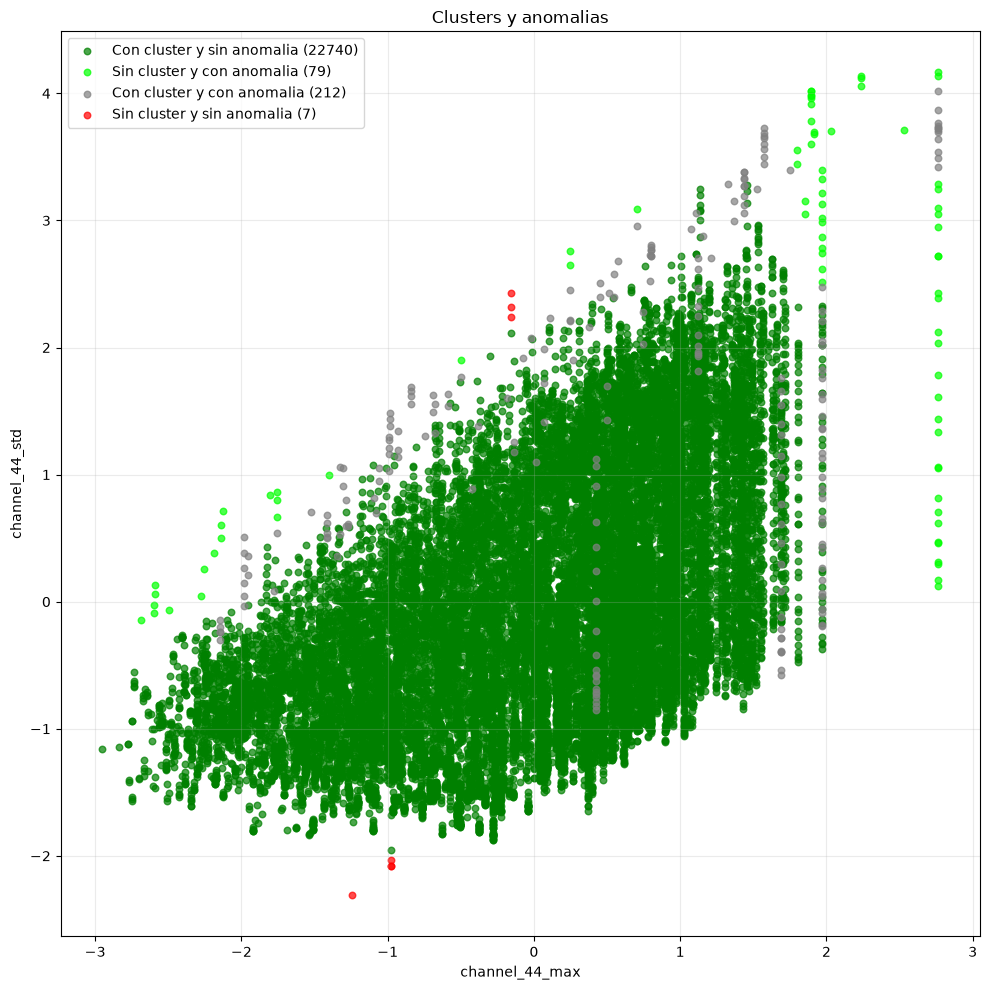

Con cluster y sin anomalia    22740
Sin cluster y con anomalia       79
Con cluster y con anomalia      212
Sin cluster y sin anomalia        7
Name: cantidad, dtype: int64

In [131]:
# En DBSCAN, cluster == -1 representa ruido: un punto sin cluster.
con_cluster = X["cluster"] != -1
sin_cluster = X["cluster"] == -1
es_anomalia = X["anomaly"] == 1

situaciones = {
    "Con cluster y sin anomalia": con_cluster & (es_anomalia==0),
    "Sin cluster y con anomalia": sin_cluster & es_anomalia,
    "Con cluster y con anomalia": con_cluster & es_anomalia,
    "Sin cluster y sin anomalia": sin_cluster & (es_anomalia==0)
}

conteo_situaciones = pd.Series(
    {nombre: mascara.sum() for nombre, mascara in situaciones.items()},
    name="cantidad",
)

df_con_cluster_sin_anomalia = X.loc[situaciones["Con cluster y sin anomalia"]]
df_sin_cluster_anomalia     = X.loc[situaciones["Sin cluster y con anomalia"]]
df_con_cluster_anomalia     = X.loc[situaciones["Con cluster y con anomalia"]]
df_sin_cluster_sin_anomalia = X.loc[situaciones["Sin cluster y sin anomalia"]]


colores = {
    "Con cluster y sin anomalia": "green",
    "Sin cluster y con anomalia": "lime", # Perfecto
    "Con cluster y con anomalia": "grey", # Falso negativo
    "Sin cluster y sin anomalia": "red" # Falso positivo
}

fig, ax = plt.subplots(figsize=(10, 10))
for nombre, mascara in situaciones.items():
    puntos = df_dbscan.loc[mascara]
    ax.scatter(
        puntos["channel_44_max"],
        puntos["channel_44_std"],
        s=22,
        alpha=0.7,
        color=colores[nombre],
        label=f"{nombre} ({len(puntos)})",
    )

ax.set_xlabel("channel_44_max")
ax.set_ylabel("channel_44_std")
ax.set_title("Clusters y anomalias")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

conteo_situaciones

Si, hay falsos positivos (7) y hay falsos negativos (212). Siempre depende pero existiendo los verdaderos positivos (79) los falsos negativos podrian no ser un problema. Por otro lado los falsos positivos si pueden serlo. En un centro de operaciones no los falsos positivos no son bienvenidos. Desvian la atencion de los problemas reales.

-----------------